## 1. In K-Means, the user must pre-define the number of clusters, 𝑘. You are given a dataset of customer purchase histories and asked to segment them.
* ## Task: Implement the K-Means algorithm from scratch for values of 𝑘 ranging from 1 to 10. Plot the Within-Cluster Sum of Squares (Inertia) against 𝑘.
* ## The Question: Identify the "elbow" point in your plot. Why does inertia always decrease as 𝑘 increases, and why would choosing 𝑘 = 20 for a dataset of only 100 points be a bad idea even if the inertia is very low?

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Create dataset with 3 natural clusters
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)


In [21]:

def kmeans(X, k, max_iter=100):
    n_samples, n_features = X.shape
    
   
    centroids = X[np.random.choice(n_samples, k, replace=False)]
    
    for _ in range(max_iter):
        
       
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        
  

        labels = np.argmin(distances, axis=1)
        
 
        new_centroids = np.array([
            X[labels == i].mean(axis=0) for i in range(k)
        ])
        
        if np.all(centroids == new_centroids):
            break
            
        centroids = new_centroids
    
  
    inertia = 0
    for i in range(k):
        cluster_points = X[labels == i]
        inertia += np.sum((cluster_points - centroids[i])**2)
    
    return inertia


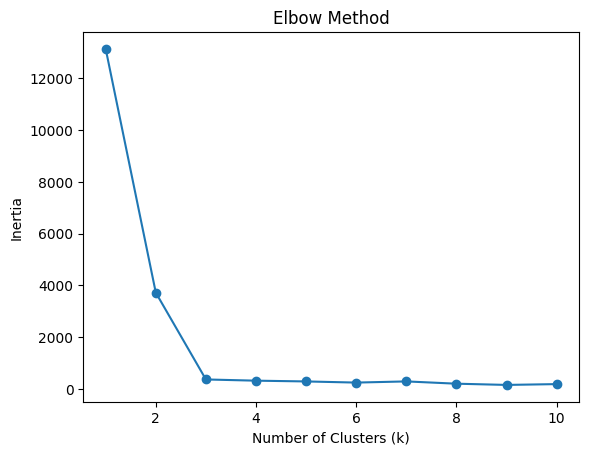

In [23]:
inertia_values = []

for k in range(1, 11):
    inertia = kmeans(X, k)
    inertia_values.append(inertia)

plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Why does inertia always decrease as k increases?

Because adding more clusters reduces distance between points and their nearest centroid.
With k = n, inertia becomes zero.

Why is k = 20 bad for 100 points?

* Overfitting

* Clusters become too small

* Poor generalization

* No meaningful segmentation